In [263]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.interpolate import UnivariateSpline
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import curve_fit
import surfinBH
import gwsurrogate as gws
import lal
lal.swig_redirect_standard_output_error(True)


True

In [235]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.50_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

In [214]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


In [278]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [279]:
def get_0PN_precessing(q_prec, chi1_vecs, chi2_vecs, a_arr):

    a_arr = np.asarray(a_arr, dtype=float)
    chi1_vecs = np.asarray(chi1_vecs, dtype=float)
    chi2_vecs = np.asarray(chi2_vecs, dtype=float)

    m1 = q_prec / (1.0 + q_prec)
    m2 = 1.0 / (1.0 + q_prec)
    eta = m1 * m2

    with np.errstate(divide='ignore', invalid='ignore'):
  
        gamma = 1.0 / a_arr

        E_bind = - (eta * gamma) / 2.0
        M_tot = 1.0 + E_bind 

        L_orb_mag = eta / np.sqrt(gamma)
        

        L_vecs = np.zeros((3, len(a_arr)))
        L_vecs[2, :] = L_orb_mag
        
        S_tot_vecs = chi1_vecs * (m1**2) + chi2_vecs * (m2**2)
    
        J_vecs = L_vecs + S_tot_vecs
        J_tot_mag = np.linalg.norm(J_vecs, axis=0)
        
    S_inst = entropy(M_tot, J_tot_mag)
    
    return {
        "q_prec": q_prec,
        "m1": m1,
        "m2": m2,
        "eta": eta,
        "a": a_arr,
        "gamma": gamma,
        "E_bind": E_bind,
        "M_tot": M_tot,
        "L_orb_mag": L_orb_mag,
        "L_vecs": L_vecs,
        "S_tot_vecs": S_tot_vecs,
        "J_vecs": J_vecs,
        "J_tot_mag": J_tot_mag,
        "S_inst": S_inst
    }

In [280]:
def get_merger_separation_NR(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01):
    
    if q_prec < 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = np.asarray(chi2_0_vec, dtype=float)
        chi_surr_2 = np.asarray(chi1_0_vec, dtype=float)
    else:
        q_surr = q_prec
        chi_surr_1 = np.asarray(chi1_0_vec, dtype=float)
        chi_surr_2 = np.asarray(chi2_0_vec, dtype=float)
        
    chi_surr_1 = chi_surr_1.flatten()
    chi_surr_2 = chi_surr_2.flatten()

    t, h, _ = sur_wave_precessing(
        q_surr,
        chi_surr_1,
        chi_surr_2,
        dt=0.1,
        f_low=f_low
    )

    amp_tot_sq = np.zeros_like(t, dtype=float)

    omega_orb_num = np.zeros_like(t, dtype=float)
    omega_orb_den = np.zeros_like(t, dtype=float)

    for mode, h_lm in h.items():

        ell, m = mode

        h_lm = np.asarray(h_lm, dtype=complex)

        amp_lm_sq = np.abs(h_lm)**2
        amp_tot_sq += amp_lm_sq

        if m == 0:
            continue

        phase_lm = np.unwrap(np.angle(h_lm))
        omega_lm = np.abs(np.gradient(phase_lm, t))

        omega_orb_lm = omega_lm / abs(m)

        omega_orb_num += amp_lm_sq * omega_orb_lm
        omega_orb_den += amp_lm_sq

    A_tot = np.sqrt(amp_tot_sq)

    omega_orb = np.full_like(t, np.nan, dtype=float)
    mask = omega_orb_den > 0.0
    omega_orb[mask] = omega_orb_num[mask] / omega_orb_den[mask]

    r_inst = np.full_like(t, np.nan, dtype=float)
    mask = np.isfinite(omega_orb) & (omega_orb > 0.0)
    r_inst[mask] = omega_orb[mask]**(-2.0 / 3.0)

    idx_merger = np.argmax(A_tot)
    r_merger = r_inst[idx_merger]

    return r_merger, t, r_inst

In [281]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [282]:
with open(file_path, 'r') as f:
    f.readline() 
    header_line = f.readline() 

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))
theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a_prec = df['separation_M']
th1 = df['theta1_rad']
th2 = df['theta2_rad']
dphi = df['deltaphi_rad']

chi1_0_x = chi1 * np.sin(theta1_0_rad) * np.cos(phi1_0_rad)
chi1_0_y = chi1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad) 
chi1_0_z = chi1 * np.cos(theta1_0_rad)
chi1_0_vec = np.array([chi1_0_x, chi1_0_y, chi1_0_z])

chi2_0_x = chi2 * np.sin(theta2_0_rad) * np.cos(phi2_0_rad)
chi2_0_y = chi2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
chi2_0_z = chi2 * np.cos(theta2_0_rad)
chi2_0_vec = np.array([chi2_0_x, chi2_0_y, chi2_0_z])

chi1_x = chi1 * np.sin(th1)
chi1_y = np.zeros_like(th1)
chi1_z = chi1 * np.cos(th1)
chi1_vec = np.array([chi1_x, chi1_y, chi1_z]) 

chi2_x = chi2 * np.sin(th2) * np.cos(dphi)
chi2_y = chi2 * np.sin(th2) * np.sin(dphi)
chi2_z = chi2 * np.cos(th2)
chi2_vec = np.array([chi2_x, chi2_y, chi2_z])

m1 = q_prec / (1.0 + q_prec)
m2 = 1.0 / (1.0 + q_prec)

In [283]:
# surrogate prediction
q_surr = 1/q_prec
mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(q_surr, chi1_0_vec, chi2_0_vec)
chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy (mf_surr, Jf_surr)
a_merger, t, a_inst = get_merger_separation_NR(q_surr, chi1_0_vec, chi2_0_vec, f_low=0.01)
print (a_merger)
print (ent_surr)

3.1162684912524288
9.994043841747649


In [284]:
res_0PN = get_0PN_precessing(q_prec, chi1_vec, chi2_vec, a_prec)
a_0PN = res_0PN["a"]
M_0PN = res_0PN["M_tot"]
J_0PN = res_0PN["J_tot_mag"]
S_0PN = res_0PN["S_inst"]

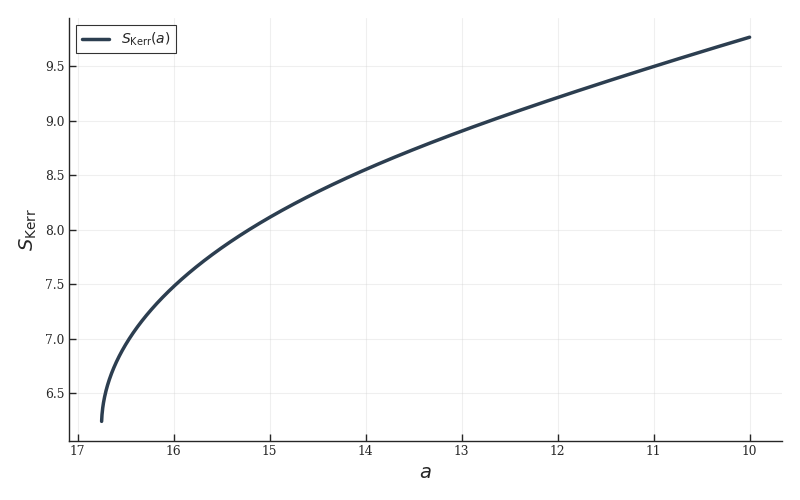

In [293]:
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_0PN, S_0PN, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5)
ax.invert_xaxis()
ax.set_xlabel(r"$a$") 
ax.set_ylabel(r"$S_{\rm Kerr}$") 
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()

plt.show()

Padè

In [298]:
valid_mask = ~np.isnan(S_0PN)
a_valid = a_0PN[valid_mask]
M_valid = M_0PN[valid_mask]
J_valid = J_0PN[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S_0PN[valid_mask][sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)

initial_guess = [1.0, 1.0, 1.0, 1.0]
lower_bounds = [-np.inf, -np.inf, -np.inf, 0.0]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

popt_M, _ = curve_fit(pade_2_1, x_fit, M_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)
popt_J, _ = curve_fit(pade_2_1, x_fit, J_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)
a_extrap = np.linspace(15, 1.0, 10000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = pade_2_1(x_extrap, *popt_M)
J_extrap = pade_2_1(x_extrap, *popt_J)
ENT_extrap = entropy(M_extrap, J_extrap)

a_full = np.concatenate([a_fit, a_extrap])
ENT_full = np.concatenate([S_fit, ENT_extrap])

idx_max = np.nanargmax(ENT_full)
a_max_entropy = a_full[idx_max]
S_max_entropy = ENT_full[idx_max]

print(f"Maximum with Padé at a =      {a_max_entropy:.3f}")
print("2PN Padé max entropy =       ", S_max_entropy)
print("Predicted entropy =          ", ent_surr)
print("Delta a =                    ", np.abs(a_max_entropy - a_merger))

Maximum with Padé at a =      4.139
2PN Padé max entropy =        10.601764879123246
Predicted entropy =           9.994043841747649
Delta a =                     1.0228454201387098


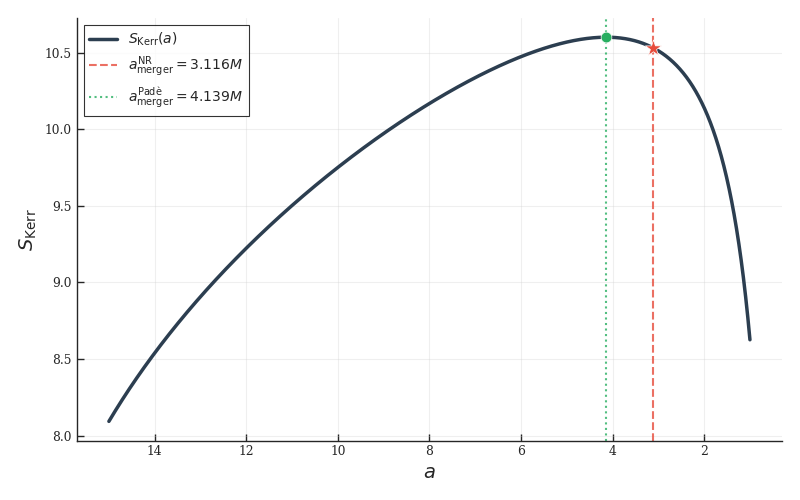

In [299]:

sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})


sort_idx = np.argsort(a_extrap)
a_sorted = a_extrap[sort_idx]
ent_sorted = ENT_extrap[sort_idx]
y_at_merger = np.interp(a_merger, a_sorted, ent_sorted)
y_at_max_entropy = np.interp(a_max_entropy, a_sorted, ent_sorted)

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(a_extrap, ENT_extrap, label=r"$S_{\rm Kerr}(a)$", color="#2c3e50", lw=2.5)
ax.scatter(a_merger, y_at_merger, marker='*', s=150, color='#e74c3c', zorder=5, edgecolor='white', linewidth=0.5)
ax.scatter(a_max_entropy, y_at_max_entropy, marker='o', s=60, color='#27ae60', zorder=5, edgecolor='white', linewidth=0.5)
ax.axvline(a_merger, color="#e74c3c", linestyle="--", lw=1.5, alpha=0.8, 
           label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax.axvline(a_max_entropy, color="#27ae60", linestyle=":", lw=1.5, alpha=0.8, 
           label=fr"$a_{{\rm merger}}^{{\rm Padè}}={a_max_entropy:.3f}M$")
ax.invert_xaxis()
ax.set_xlabel(r"$a$") 
ax.set_ylabel(r"$S_{\rm Kerr}$")           
ax.legend(frameon=True, shadow=False, fancybox=False, edgecolor="black", loc='best')
sns.despine()
plt.tight_layout()
plt.show()